In [ ]:
# import libraries
import math
import os
import pickle
import random
import time
import itertools
import importlib

# import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# import Koopman Libraries
from core.koopman_core_linear import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled

# ===== import Frenet-real-state dynamics file =====
import dynamics.cacaNEW as cacaNEW

importlib.reload(cacaNEW)
from dynamics.cacaNEW import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_adapt import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics


# ===== helper for Frenet path =====
def build_test_frenet_path_from_xy(x_ref_path, y_ref_path):
    dx_seg = np.diff(x_ref_path)
    dy_seg = np.diff(y_ref_path)
    ds_seg = np.sqrt(dx_seg ** 2 + dy_seg ** 2)
    s_ref = np.concatenate(([0.0], np.cumsum(ds_seg)))

    dx = np.gradient(x_ref_path)
    dy = np.gradient(y_ref_path)
    psi_ref = np.unwrap(np.arctan2(dy, dx))

    ds = np.gradient(s_ref)
    curvature_ref = np.gradient(psi_ref) / np.maximum(ds, 1e-8)
    curvature_ref = np.nan_to_num(curvature_ref)

    return s_ref, psi_ref, curvature_ref


# ===== Frenet -> Cartesian for plotting =====
def frenet_to_global(s_arr, ey_arr, s_ref_path, x_ref_path, y_ref_path, psi_ref_path):
    x_center = np.interp(s_arr, s_ref_path, x_ref_path)
    y_center = np.interp(s_arr, s_ref_path, y_ref_path)
    psi_center = np.interp(s_arr, s_ref_path, psi_ref_path)

    x_global = x_center - ey_arr * np.sin(psi_center)
    y_global = y_center + ey_arr * np.cos(psi_center)
    return x_global, y_global


def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.array(x)


def scale_state(x_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(x_raw).reshape(1, -1)).flatten()


def scale_state_batch(X_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(X_raw))


def decode_scaled_to_raw(x_scaled, standardizer_x):
    return standardizer_x.inverse_transform(np.asarray(x_scaled).reshape(1, -1)).flatten()


# =============================================================================
# 系统拟合
# =============================================================================
linear = True

# =============================================================================
# 数据生成
# =============================================================================
sys_pars = {}

# 6 states: x=[s, e_y, e_psi, v_x, v_y, r]
num_states = 6
num_inputs = 2
dt = 0.02

sys_pars["num_states"] = num_states
sys_pars["num_inputs"] = num_inputs
sys_pars["dt"] = dt

# nominal vehicle parameters
sys_pars["m"] = 1500.0
sys_pars["Iz"] = 2250.0
sys_pars["lf"] = 1.2
sys_pars["lr"] = 1.6
sys_pars["Cf"] = 80000.0
sys_pars["Cr"] = 80000.0
sys_pars["vx_ref"] = 3.0
sys_pars["curvature_ref"] = 0.0

# input generation
sys_pars["U_type"] = "sinusoidal"
sys_pars["delta_max"] = 0.05
sys_pars["ax_max"] = 0.6

# uncertainty setting
sys_pars["uncertainty"] = "NA"
sys_pars["amp"] = 0.0
sys_pars["freq"] = 1.0

sys_pars_new = {}

sys_pars_new["num_states"] = num_states
sys_pars_new["num_inputs"] = num_inputs
sys_pars_new["dt"] = dt

# changed vehicle parameters (keep speed matched for stable baseline)
sys_pars_new["m"] = 1650.0
sys_pars_new["Iz"] = 2400.0
sys_pars_new["lf"] = 1.2
sys_pars_new["lr"] = 1.6
sys_pars_new["Cf"] = 70000.0
sys_pars_new["Cr"] = 70000.0
sys_pars_new["vx_ref"] = 3.0
sys_pars_new["curvature_ref"] = 0.0

sys_pars_new["U_type"] = sys_pars["U_type"]
sys_pars_new["delta_max"] = sys_pars["delta_max"]
sys_pars_new["ax_max"] = sys_pars["ax_max"]

# for stable baseline, remove time-varying uncertainty first
sys_pars_new["uncertainty"] = "NA"
sys_pars_new["amp"] = 0.0
sys_pars_new["freq"] = 1.0

sensor_noise = False
SNR_DB = 30

num_traj = 400
num_train = int(0.8 * num_traj)
num_val = num_traj - num_train
num_snaps = 200

X, X_changed, U = single_vehicle_data_gen_multi(
    num_traj, num_snaps, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)
print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)

os.makedirs("saved_data/single_vehicle", exist_ok=True)

np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)

with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB
    }, f)

print("离线数据已保存。")

state_labels = ["s", "e_y", "e_psi", "v_x", "v_y", "r"]
input_labels = ["delta", "a_x"]
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:

# =============================================================================
# Learning Koopman
# =============================================================================
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

print("xs_train shape:", xs_train.shape)
print("us_train shape:", us_train.shape)

net_params_lin = {}
net_params_lin["state_dim"] = num_states
net_params_lin["ctrl_dim"] = num_inputs
net_params_lin["encoder_hidden_width"] = 128
net_params_lin["encoder_hidden_depth"] = 3
net_params_lin["encoder_output_dim"] = 16
net_params_lin["optimizer"] = "adam"
net_params_lin["activation_type"] = "tanh"
net_params_lin["lr"] = 2e-4
net_params_lin["epochs"] = 300
net_params_lin["batch_size"] = 256

net_params_lin["eig_loss"] = True
net_params_lin["eig_loss_coeff"] = 1.0
net_params_lin["lifted_loss_penalty"] = 1.0

net_params_lin["l2_reg"] = 1e-5
net_params_lin["l1_reg"] = 1e-7
net_params_lin["first_obs_const"] = True
net_params_lin["override_C"] = True
net_params_lin["dt"] = dt

train = True
standardize = True

os.makedirs("saved_models/single_vehicle/linear", exist_ok=True)

file_koop_linear = (
        "saved_models/single_vehicle/linear/"
        + "Koop_vehicle_Dim"
        + str(net_params_lin["encoder_output_dim"])
        + "_dt_"
        + str(dt)
        + ".pth"
)

print("Model save path:", file_koop_linear)

standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)
    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )
    model_koop_dnn_lin.model_pipeline(net_params_lin)
    model_koop_dnn_lin.construct_koopman_model()

    torch.save(model_koop_dnn_lin, file_koop_linear)
else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE

print("Model parameter device:", next(model_koop_dnn_lin.net.parameters()).device)

train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
epochs = np.arange(0, net_params_lin["epochs"])

plt.figure(figsize=(15, 8))
plt.plot(epochs, train_loss, color="tab:orange", label="Training loss")
plt.plot(epochs, train_pred_loss, "--", color="tab:orange", label="Training prediction loss")
plt.plot(epochs, train_lifted_loss, ":", color="tab:orange", label="Training lifted loss")
plt.plot(epochs, val_loss, color="tab:blue", label="Validation loss")
plt.plot(epochs, val_pred_loss, "--", color="tab:blue", label="Validation prediction loss")
plt.plot(epochs, val_lifted_loss, ":", color="tab:blue", label="Validation lifted loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.show()

Using device: cuda
GPU: NVIDIA GeForce RTX 5080
X shape: (400, 200, 6)
X_changed shape: (400, 200, 6)
U shape: (400, 199, 2)
离线数据已保存。


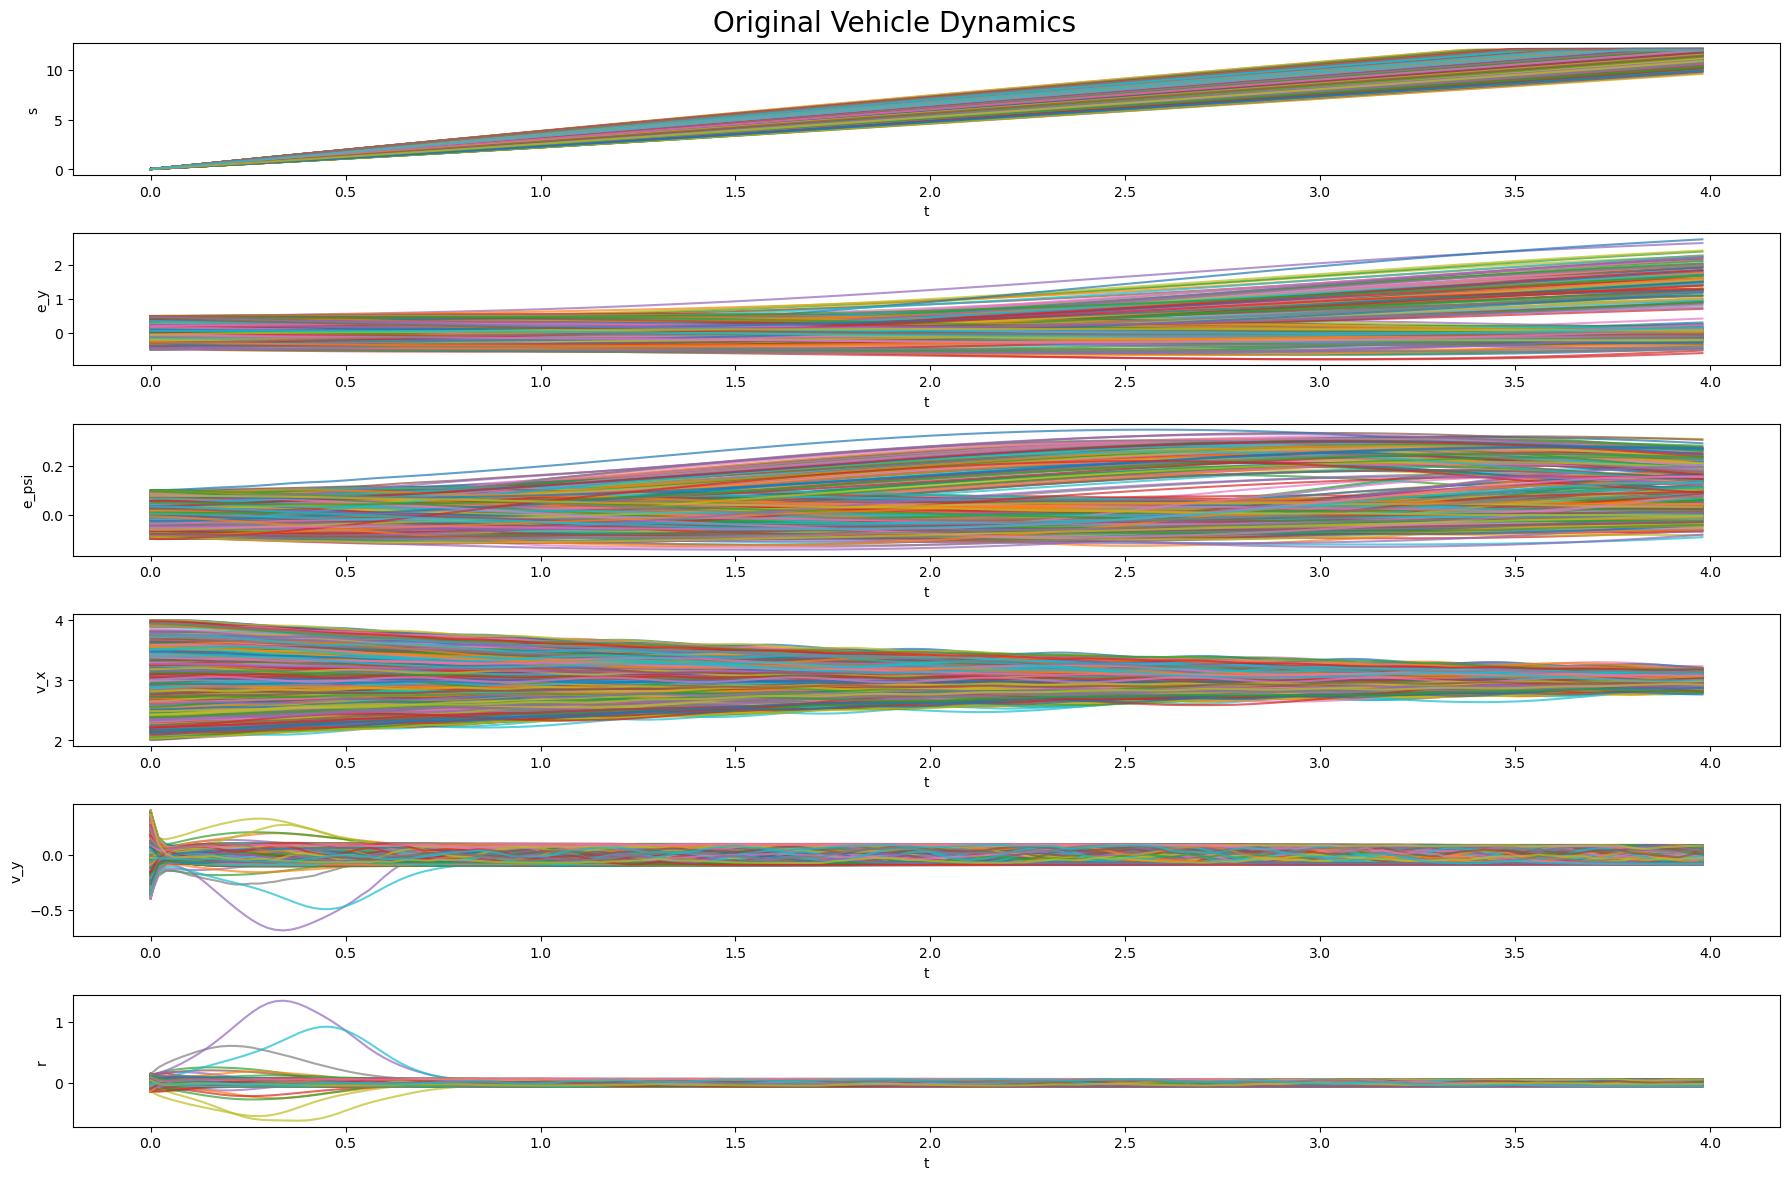

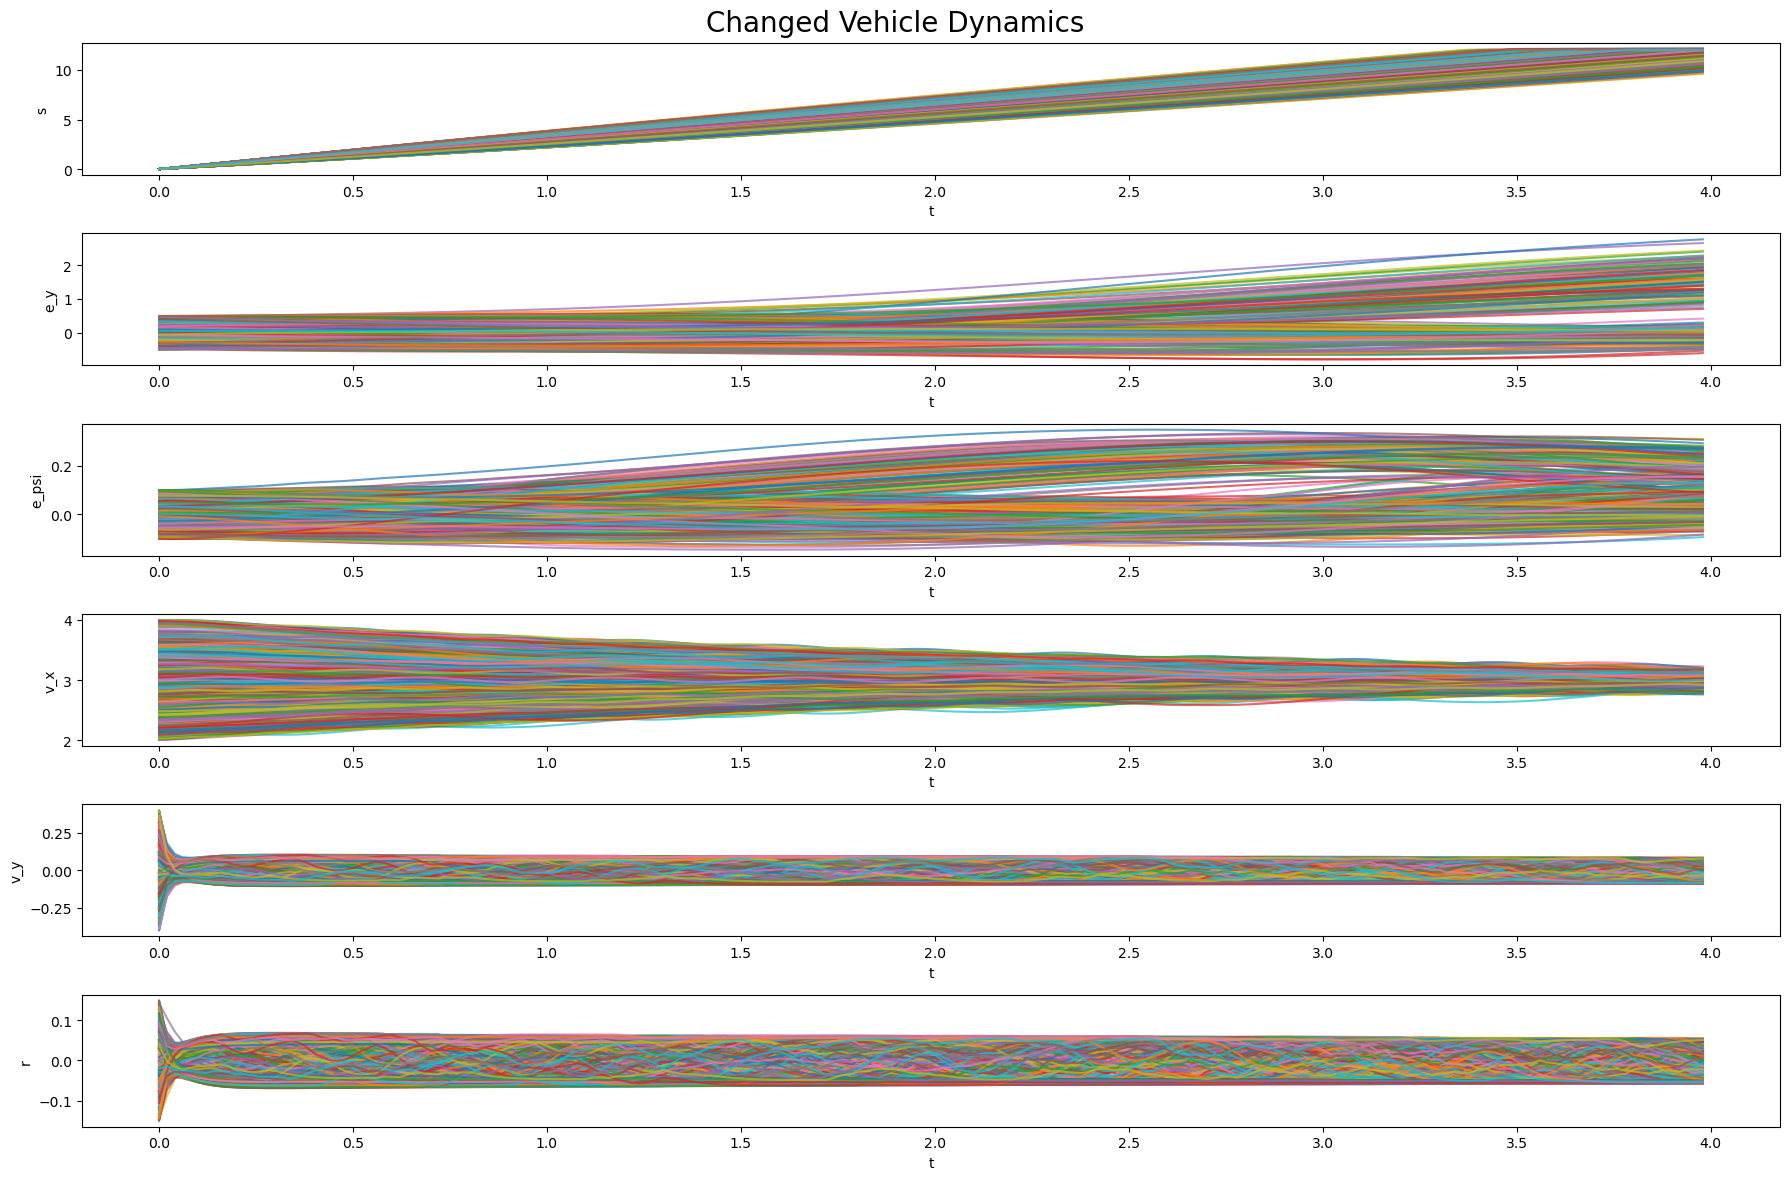

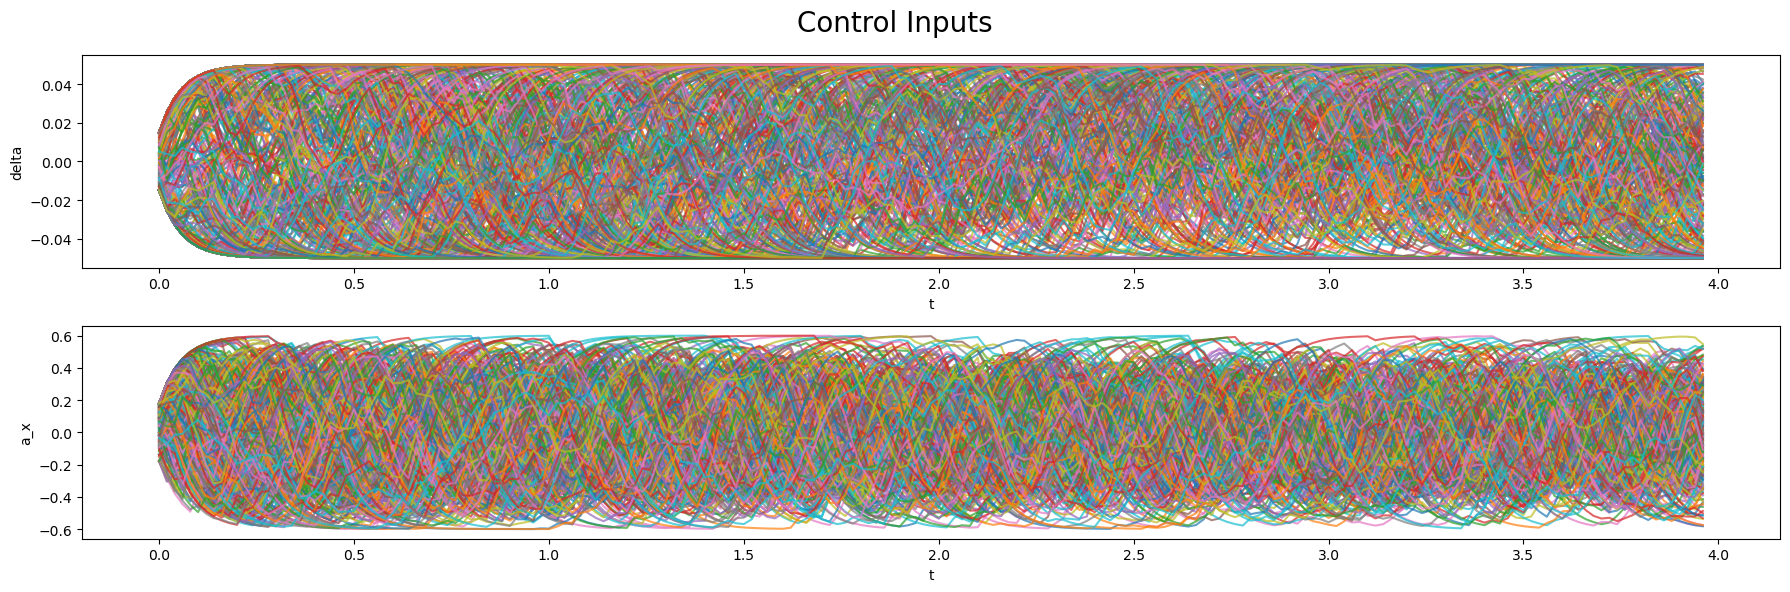

xs_train shape: (320, 200, 6)
us_train shape: (320, 199, 2)
Model save path: saved_models/single_vehicle/linear/Koop_vehicle_Dim16_dt_0.02.pth
Epoch   1: train loss: 2.1936417825, validation loss: 1.0778504690
Epoch   2: train loss: 0.9260214814, validation loss: 0.7917219225
Epoch   3: train loss: 0.7707228896, validation loss: 0.6885924926
Epoch   4: train loss: 0.6893427305, validation loss: 0.6247404511
Epoch   5: train loss: 0.6310209929, validation loss: 0.5730421515
Epoch   6: train loss: 0.5845609265, validation loss: 0.5347071749
Epoch   7: train loss: 0.5457894717, validation loss: 0.4973944009
Epoch   8: train loss: 0.5128124166, validation loss: 0.4669471816
Epoch   9: train loss: 0.4841350694, validation loss: 0.4431404015
Epoch  10: train loss: 0.4595628005, validation loss: 0.4190094393
Epoch  11: train loss: 0.4375776196, validation loss: 0.3974327796
Epoch  12: train loss: 0.4171953782, validation loss: 0.3806285324
Epoch  13: train loss: 0.3997908323, validation loss:

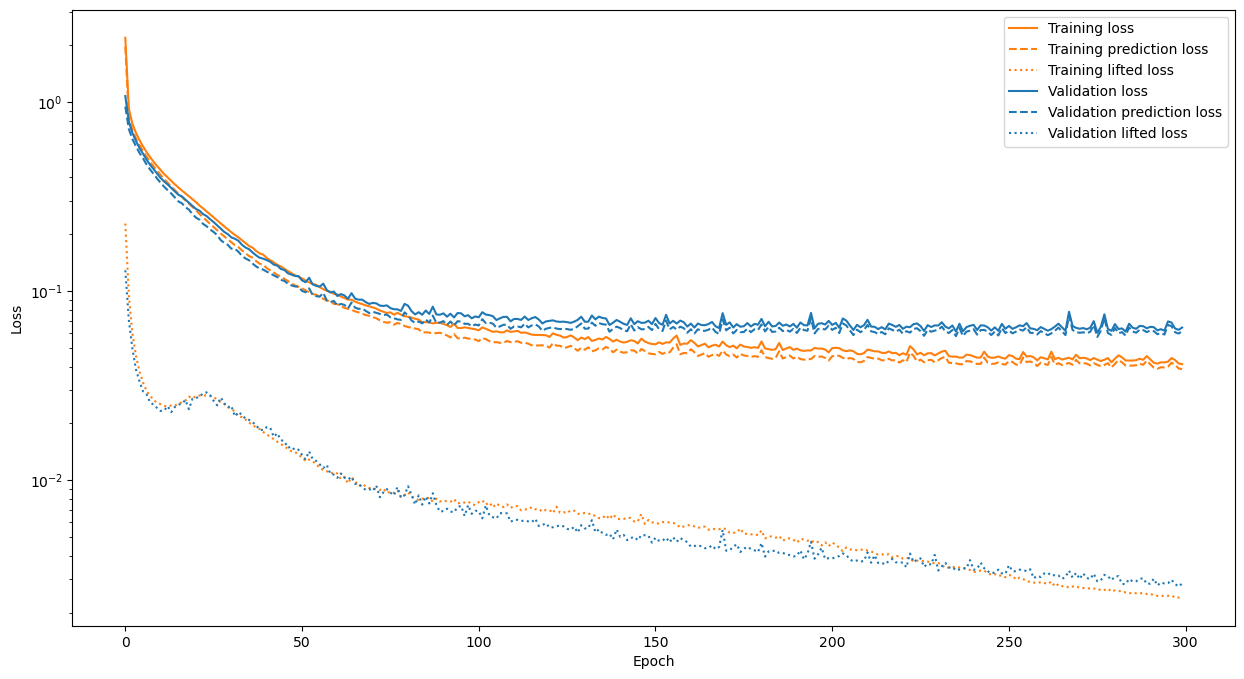

test shapes: (1, 100, 6) (1, 100, 6) (1, 99, 2)
stable spectral radius = 0.99900013
A, B, C shapes: (23, 23) (23, 2) (6, 23)
spectral radius = 1.0091581
eigvals = [0.30889323+0.j         0.3690371 +0.j         0.9647513 +0.14084812j
 0.9647513 -0.14084812j 0.98644394+0.07385622j 0.98644394-0.07385622j
 1.0044533 +0.02585247j 1.0044533 -0.02585247j 1.0018543 +0.02150797j
 1.0018543 -0.02150797j 1.0091581 +0.j         0.98882127+0.j
 0.99364454+0.00739307j 0.99364454-0.00739307j 1.0026433 +0.00428393j
 1.0026433 -0.00428393j 0.99528295+0.00380996j 0.99528295-0.00380996j
 0.99717325+0.00283093j 0.99717325-0.00283093j 1.0005596 +0.j
 1.0000005 +0.j         1.        +0.j        ]


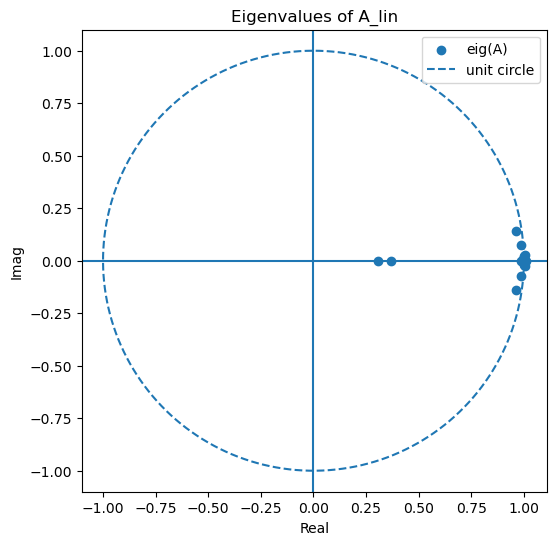

x_unchanged_scaled shape: (99, 6)
u_scaled shape: (99, 2)
x_changed_scaled shape: (99, 6)
x_changed_prime_scaled shape: (99, 6)


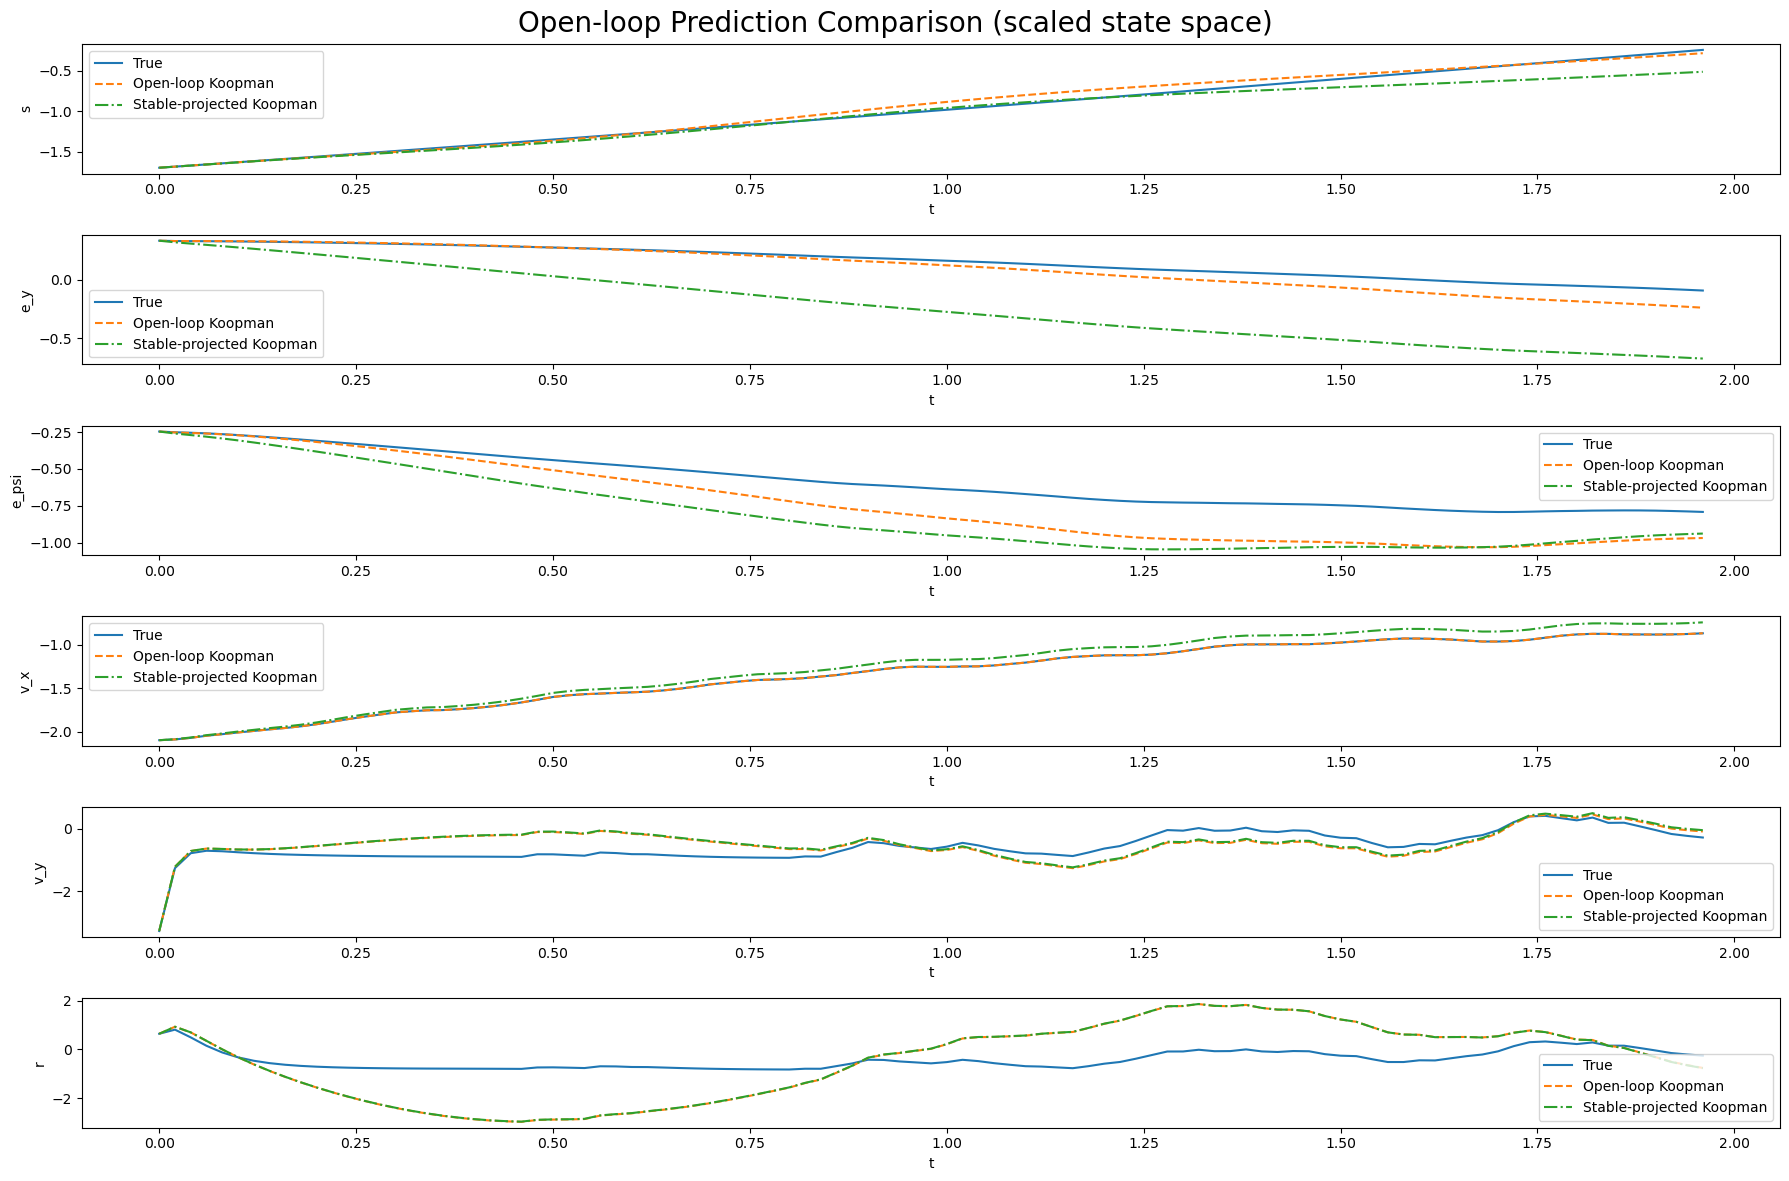

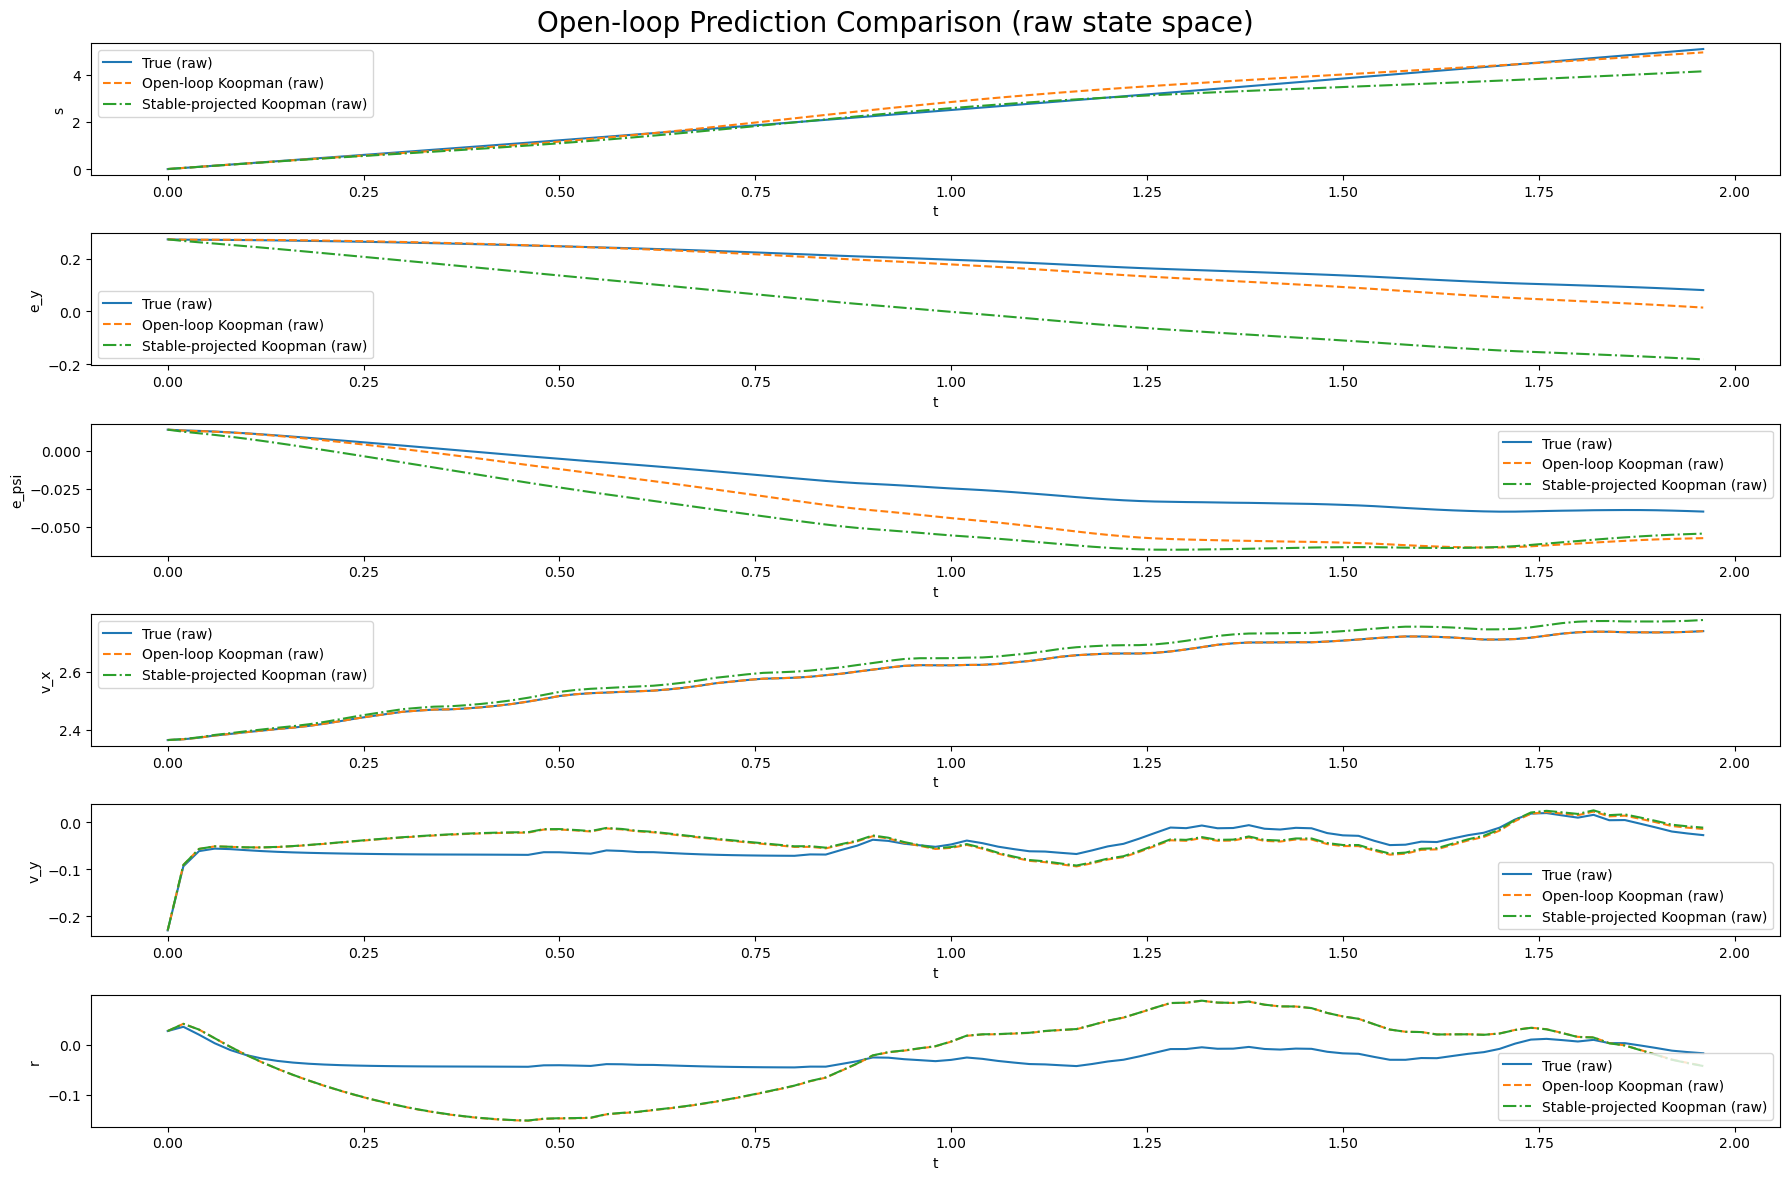

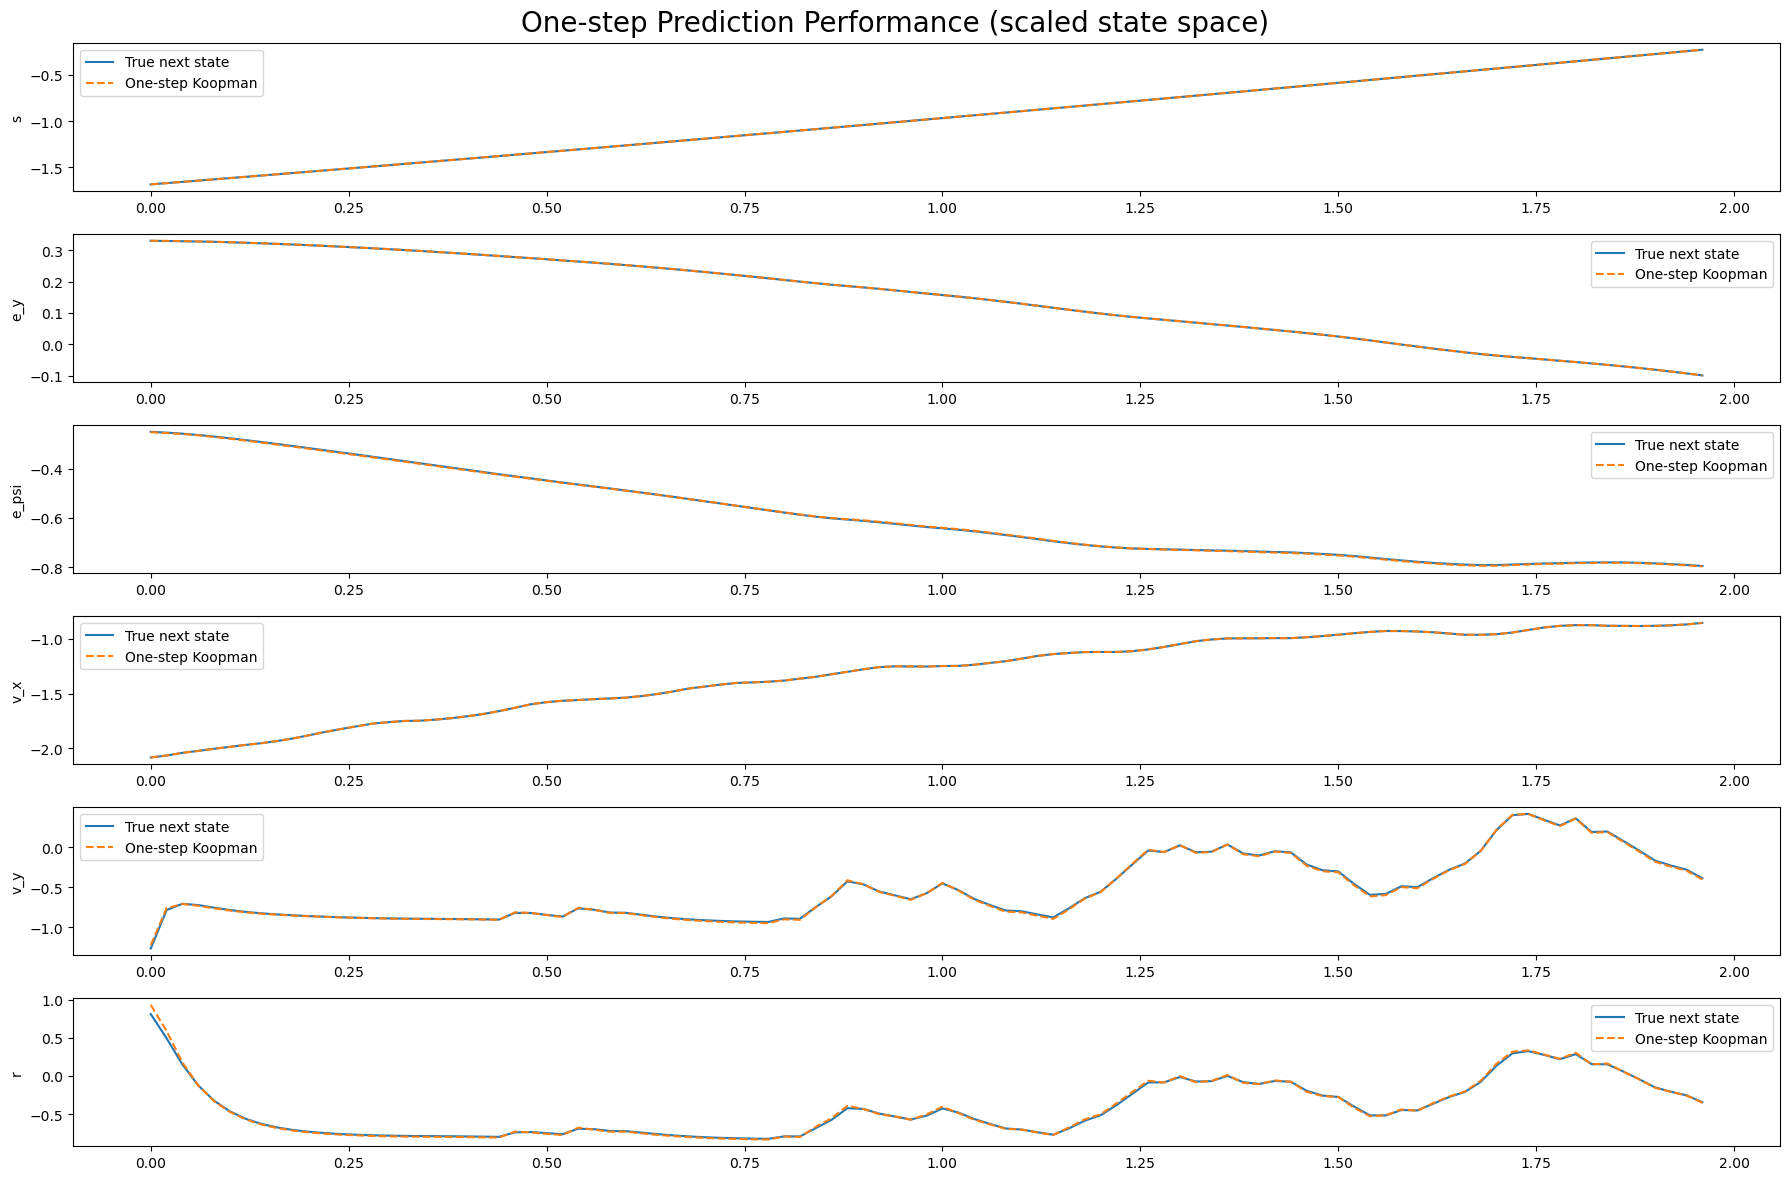

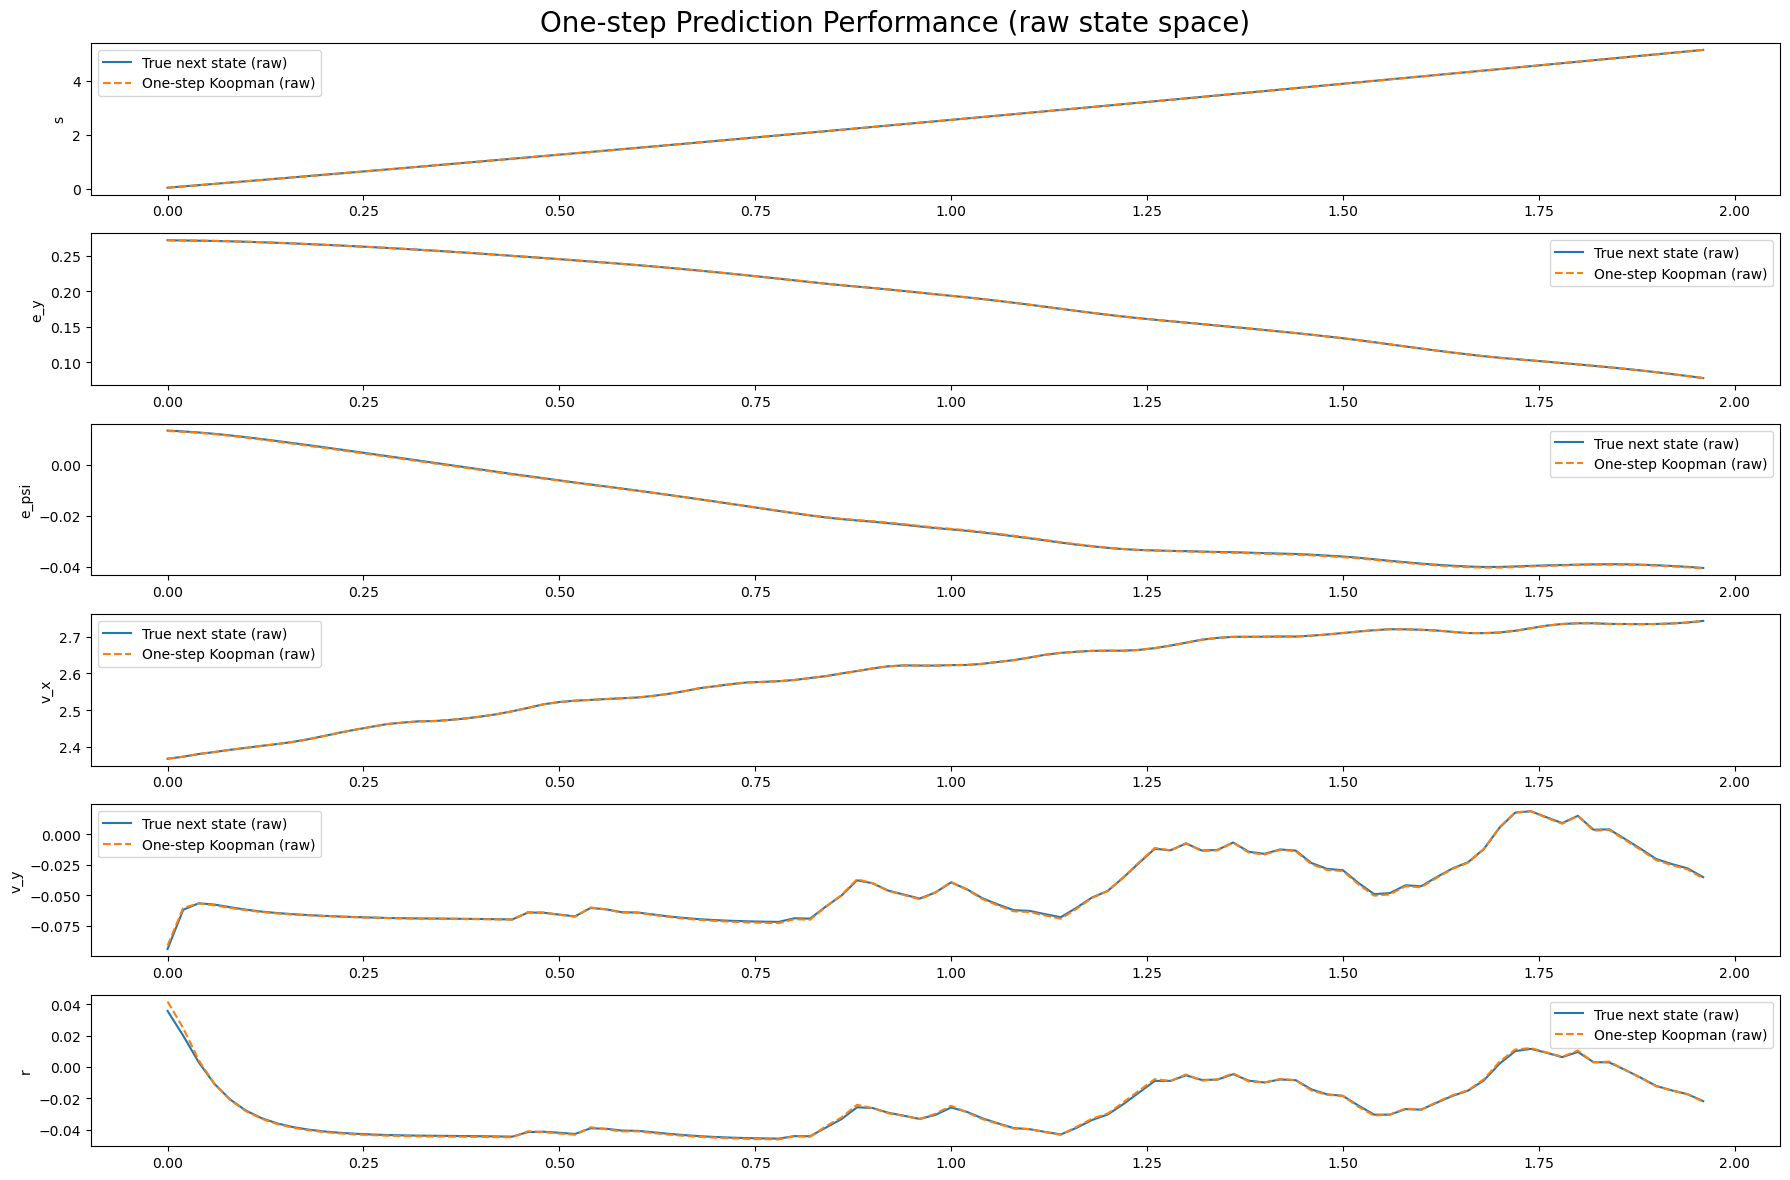

In [1]:

# =============================================================================
# Koopman Model Parameters
# =============================================================================
num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1
first_obs_const = int(net_params_lin["first_obs_const"])
override_C = net_params_lin["override_C"]
if override_C:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + first_obs_const

x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)

print("test shapes:", x_unchanged_test.shape, x_changed_test.shape, u_test.shape)

A_lin = np.array(model_koop_dnn_lin.A)
B_lin = np.array(model_koop_dnn_lin.B)
C_lin = np.array(model_koop_dnn_lin.C)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals = np.linalg.eigvals(A_lin)
spectral_radius = np.max(np.abs(eigvals))

print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label="eig(A)")
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "--", label="unit circle")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.legend()
plt.title("Eigenvalues of A_lin")
plt.axis("equal")
plt.show()

X_unchanged_scaled, _ = model_koop_dnn_lin.net.process(x_unchanged_test, data_u=u_test)
X_changed_scaled, _ = model_koop_dnn_lin.net.process(x_changed_test, data_u=u_test)

x_unchanged_scaled = X_unchanged_scaled[:, :num_states]
u_scaled = X_unchanged_scaled[:, num_states:num_states + num_inputs]
x_unchanged_prime_scaled = X_unchanged_scaled[:, num_states + num_inputs:]

x_changed_scaled = X_changed_scaled[:, :num_states]
x_changed_prime_scaled = X_changed_scaled[:, num_states + num_inputs:]

print("x_unchanged_scaled shape:", x_unchanged_scaled.shape)
print("u_scaled shape:", u_scaled.shape)
print("x_changed_scaled shape:", x_changed_scaled.shape)
print("x_changed_prime_scaled shape:", x_changed_prime_scaled.shape)

num_pred = x_unchanged_scaled.shape[0]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

z_lin[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged_scaled[:, i], label="True")
    plt.plot(T_plot, x_est_lin[:, i], "--", label="Open-loop Koopman")
    plt.plot(T_plot, x_est_lin_stable[:, i], "-.", label="Stable-projected Koopman")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_est_lin_raw = standardizer_x_kdnn.inverse_transform(x_est_lin)
x_est_lin_stable_raw = standardizer_x_kdnn.inverse_transform(x_est_lin_stable)
x_true_raw = x_unchanged_test[0, :-1, :]

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_true_raw[:, i], label="True (raw)")
    plt.plot(T_plot, x_est_lin_raw[:, i], "--", label="Open-loop Koopman (raw)")
    plt.plot(T_plot, x_est_lin_stable_raw[:, i], "-.", label="Stable-projected Koopman (raw)")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_one_step_pred = np.zeros_like(x_unchanged_prime_scaled)

for k in range(num_pred):
    z_k = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)

T_plot_1 = np.arange(x_one_step_pred.shape[0]) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_1, x_unchanged_prime_scaled[:, i], label="True next state")
    plt.plot(T_plot_1, x_one_step_pred[:, i], "--", label="One-step Koopman")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)
x_true_next_raw = x_unchanged_test[0, 1:, :]

T_plot_raw = np.arange(x_true_next_raw.shape[0]) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_raw, x_true_next_raw[:, i], label="True next state (raw)")
    plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], "--", label="One-step Koopman (raw)")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

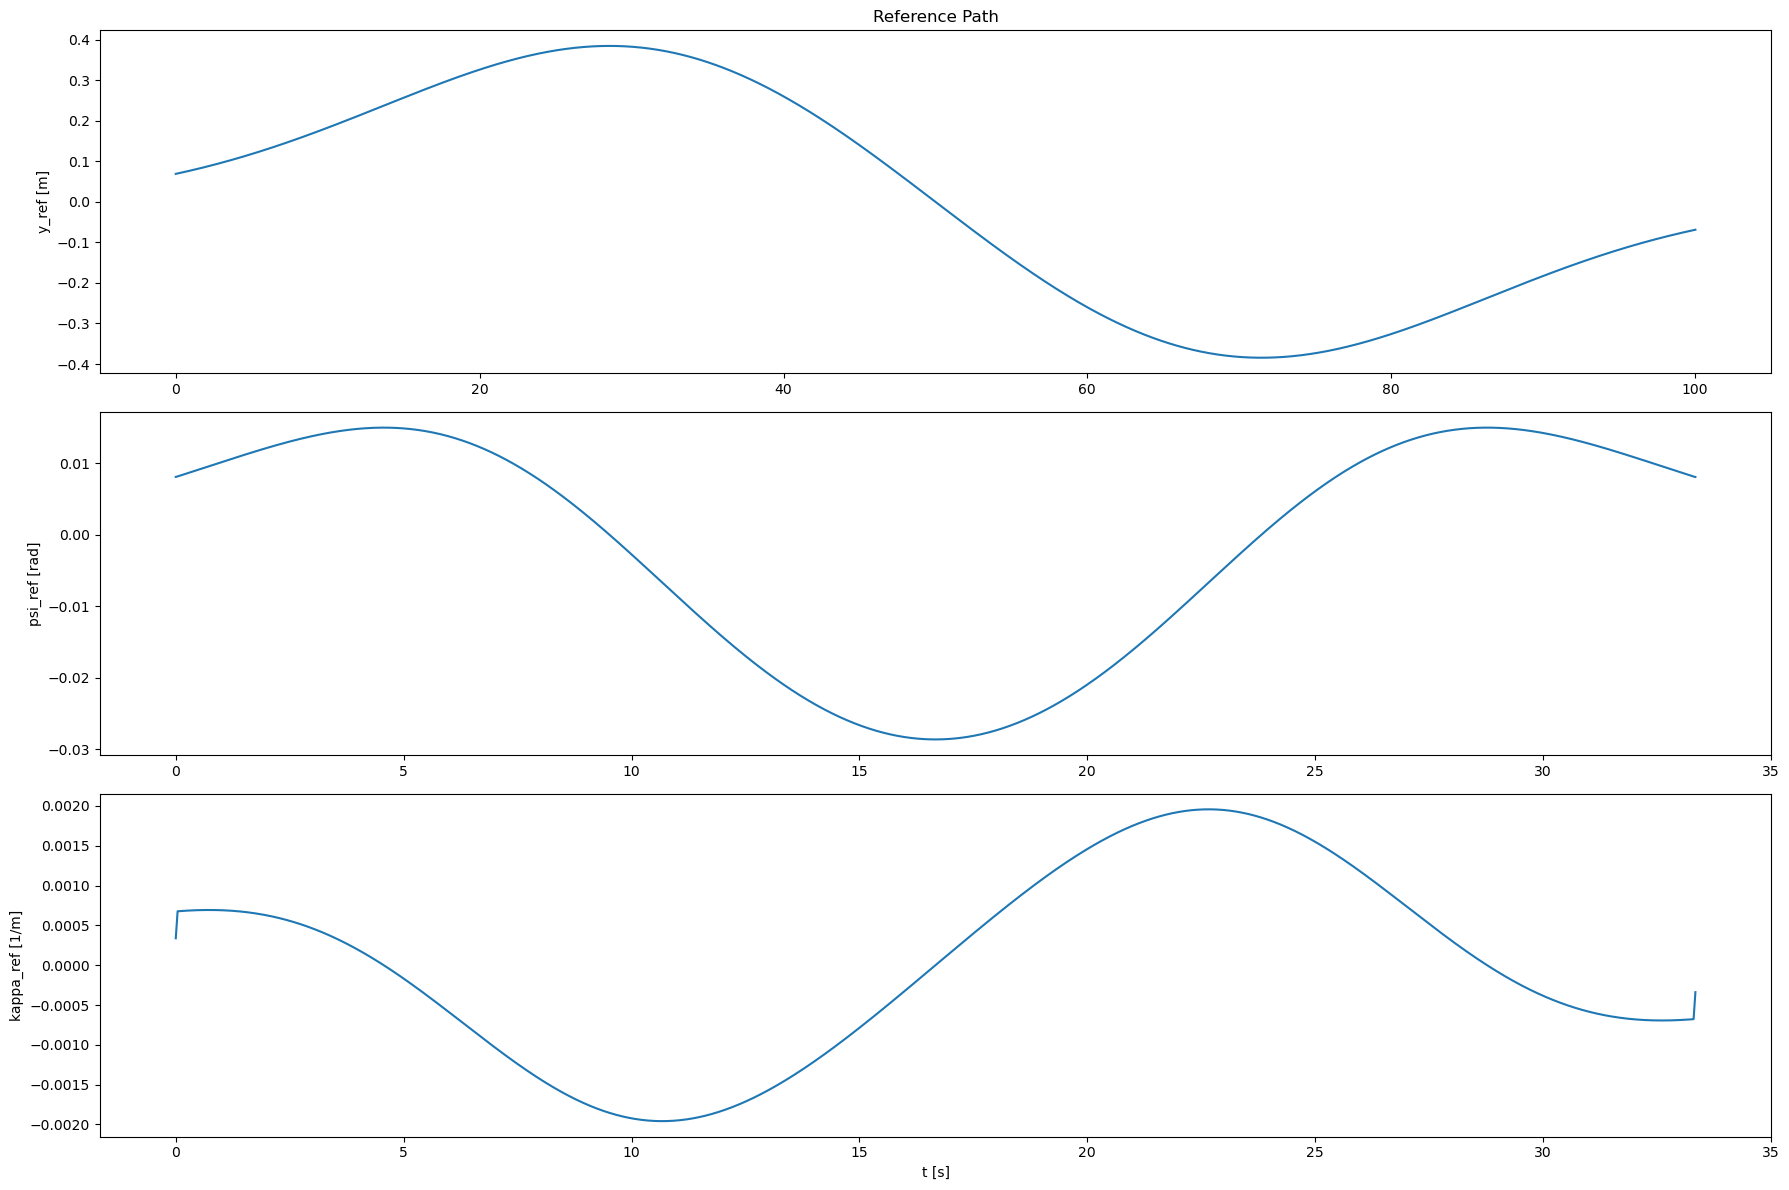

A finite: True
B finite: True
C finite: True
A shape: (23, 23) B shape: (23, 2) C shape: (6, 23)
raw spectral radius = 1.0091581
stable spectral radius = 0.99900013

========== scaled-space feasibility diagnostics ==========
x0 raw             : [0. 0. 0. 3. 0. 0.]
x0 scaled          : [-1.70016633 -0.27225349 -0.38639878 -0.01481522  0.13277194  0.09468184]
x0 decoded scaled  : [-1.7001663  -0.27225348 -0.3863988  -0.01481522  0.13277194  0.09468184]
decode err (scaled): [-1.58082822e-08  3.96997796e-09 -8.42722669e-09 -2.05758655e-10
  3.06159365e-09 -3.87747598e-10]
x0 decoded raw     : [4.7683716e-07 0.0000000e+00 0.0000000e+00 3.0000000e+00 0.0000000e+00
 0.0000000e+00]
decoded lower slack (scaled): [ 2.86643579 11.09687245 12.13787759  8.1757681  59.294412   60.28651503]
decoded upper slack (scaled): [143.32179034  11.09687244  12.1378776   16.35153619  59.294412
  60.28651503]

--- no-adapt step 0 ---
x raw             : [0. 0. 0. 3. 0. 0.]
x scaled          : [-1.70016633 -0.27

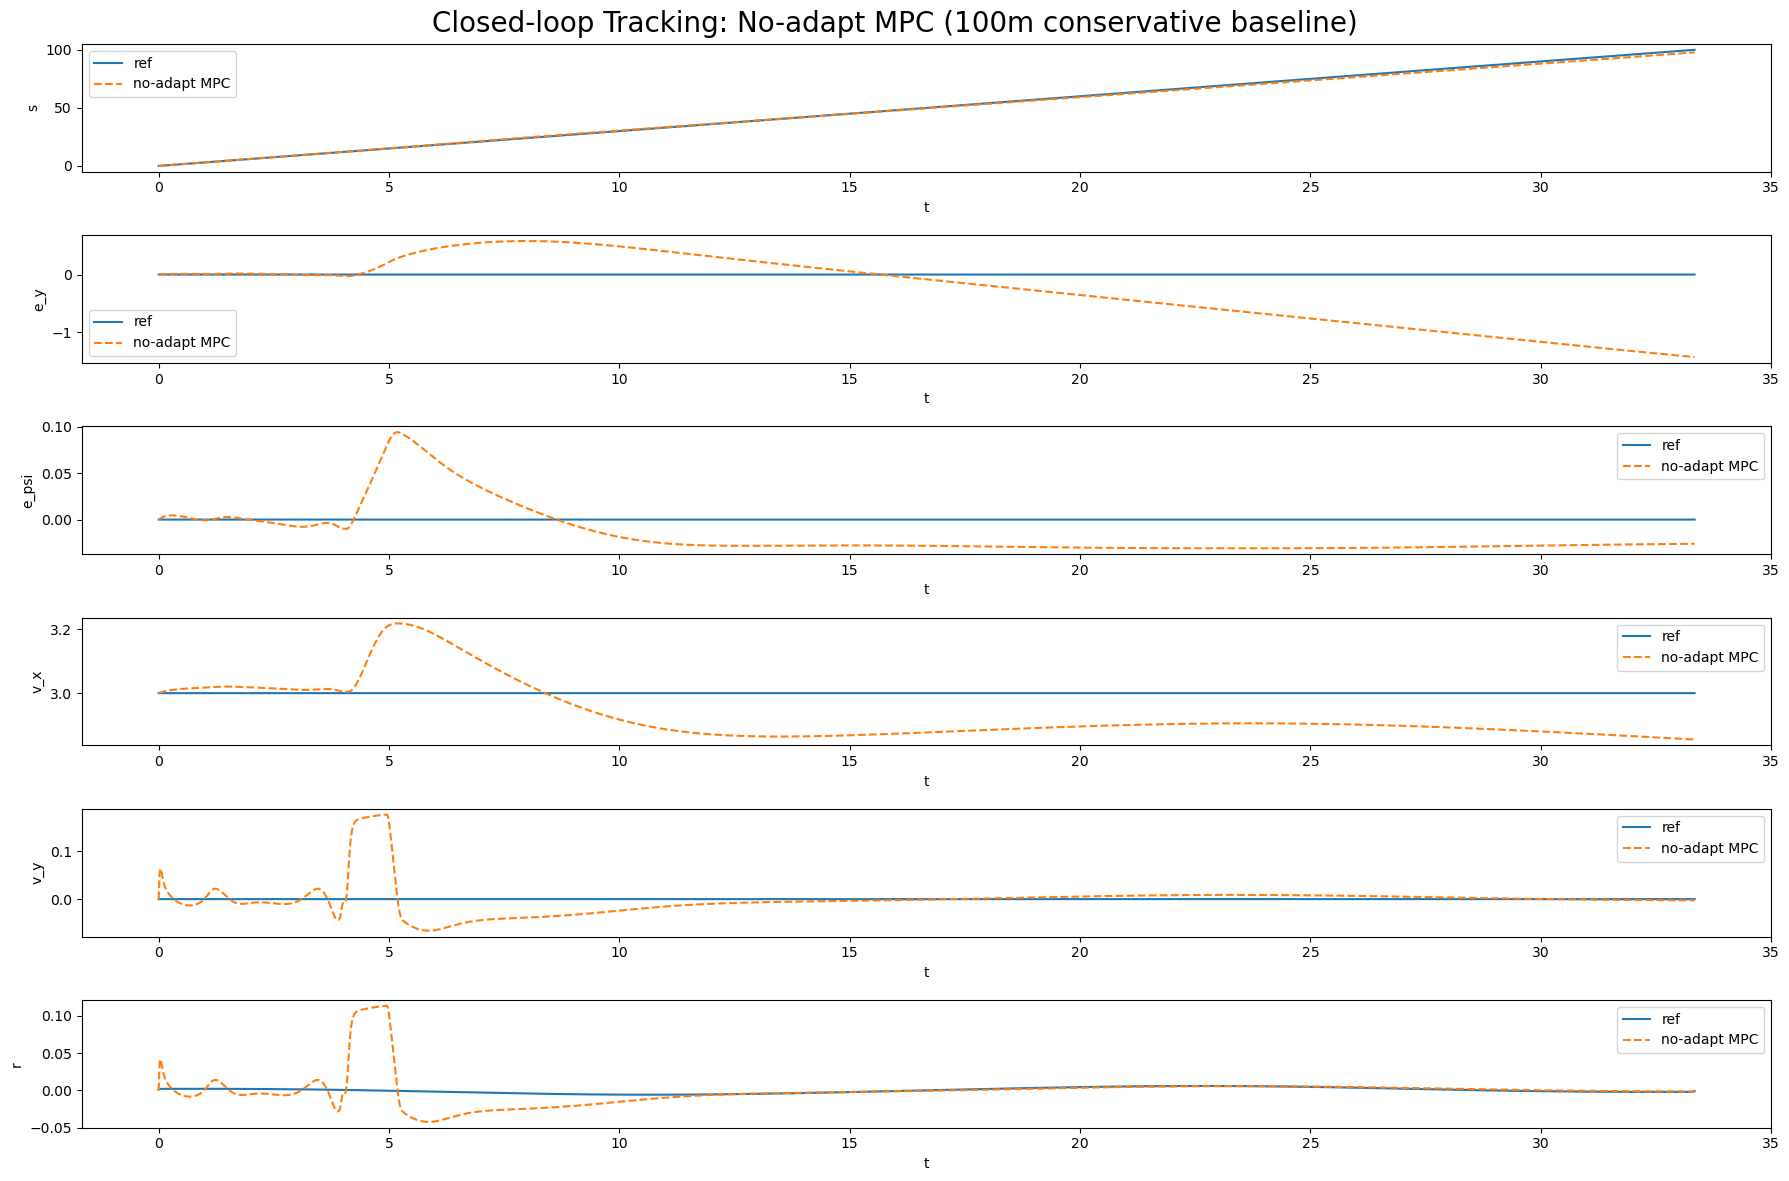

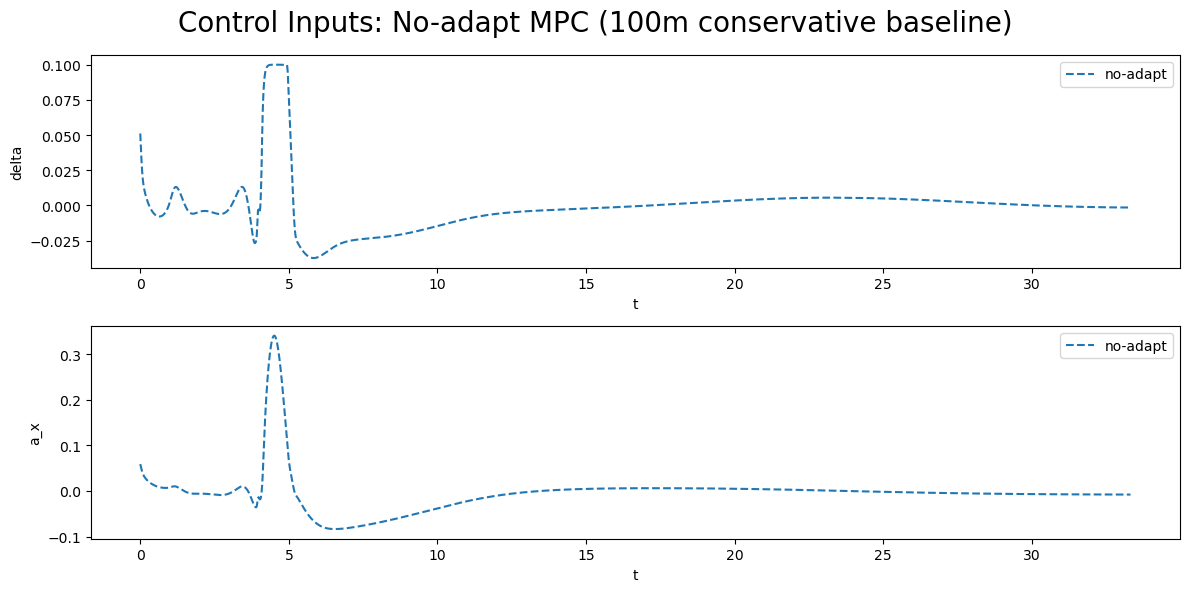

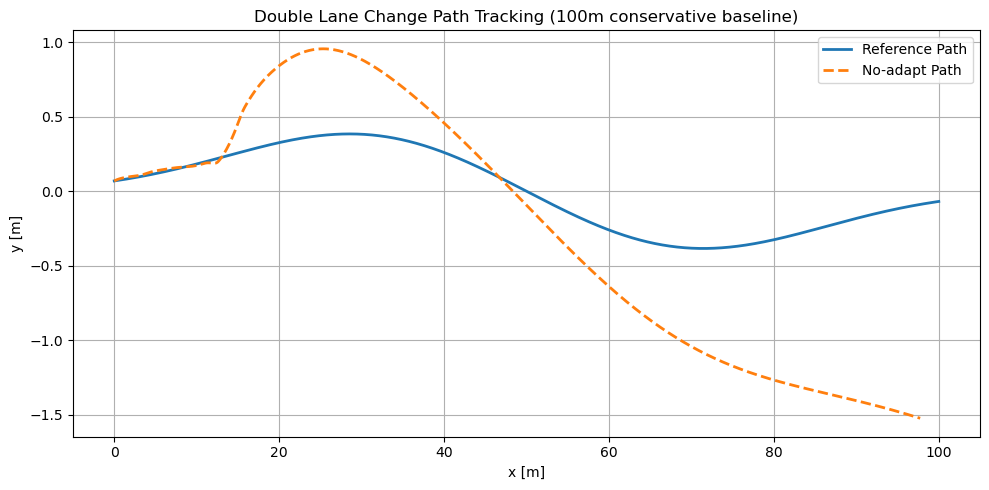

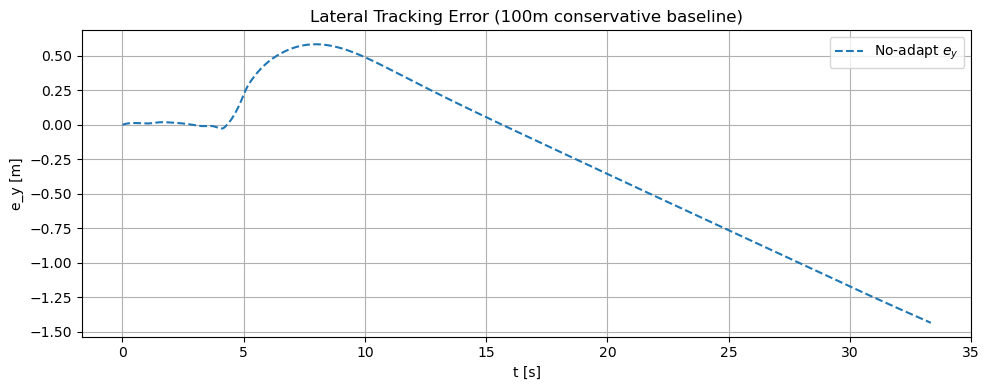

In [4]:

# =============================================================================
# Testing
# Conservative 100m no-adapt baseline
# =============================================================================

# =========================
# Reference path generation
# =========================
path_length = 100.0

vx_nom = 3.0
T_traj = path_length / vx_nom
t_ref = np.arange(0, T_traj + dt, dt)
traj_length = t_ref.size
x_path = vx_nom * t_ref

A1 = 0.4
A2 = -0.4
x1 = 30.0
x2 = 70.0
sigma1 = 16.0
sigma2 = 16.0

y_ref_path = (
        A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2)
        + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
)

s_ref_path, psi_ref_path, curvature_ref_path = build_test_frenet_path_from_xy(
    x_path, y_ref_path
)

x_ref_raw = np.zeros((num_states, traj_length))
x_ref_raw[0, :] = s_ref_path
x_ref_raw[1, :] = 0.0
x_ref_raw[2, :] = 0.0
x_ref_raw[3, :] = vx_nom
x_ref_raw[4, :] = 0.0
x_ref_raw[5, :] = vx_nom * curvature_ref_path

x_ref_scaled = standardizer_x_kdnn.transform(x_ref_raw.T).T

plt.figure(figsize=(18, 12))
plt.subplot(3, 1, 1)
plt.plot(x_path, y_ref_path)
plt.ylabel("y_ref [m]")
plt.title("Reference Path")

plt.subplot(3, 1, 2)
plt.plot(t_ref, psi_ref_path)
plt.ylabel("psi_ref [rad]")

plt.subplot(3, 1, 3)
plt.plot(t_ref, curvature_ref_path)
plt.ylabel("kappa_ref [1/m]")
plt.xlabel("t [s]")
plt.tight_layout()
plt.show()

# =========================
# Koopman matrices
# =========================
A_lin = to_numpy(model_koop_dnn_lin.A)
B_lin = to_numpy(model_koop_dnn_lin.B)
C_lin = to_numpy(model_koop_dnn_lin.C)

print("A finite:", np.all(np.isfinite(A_lin)))
print("B finite:", np.all(np.isfinite(B_lin)))
print("C finite:", np.all(np.isfinite(C_lin)))
print("A shape:", A_lin.shape, "B shape:", B_lin.shape, "C shape:", C_lin.shape)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

print("raw spectral radius =", np.max(np.abs(np.linalg.eigvals(A_lin))))
print("stable spectral radius =", np.max(np.abs(np.linalg.eigvals(A_lin_stable))))

# =========================
# Solver settings
# =========================
solver_settings = {}
solver_settings["gen_embedded_ctrl"] = False
solver_settings["warm_start"] = True
solver_settings["polish"] = False
solver_settings["polish_refine_iter"] = 3
solver_settings["scaling"] = True
solver_settings["adaptive_rho"] = True
solver_settings["check_termination"] = 25
solver_settings["max_iter"] = 30000
solver_settings["eps_abs"] = 1e-4
solver_settings["eps_rel"] = 1e-4
solver_settings["eps_prim_inf"] = 1e-3
solver_settings["eps_dual_inf"] = 1e-3

# =========================
# MPC horizon / ref preview
# =========================
N_lin_noadapt = 60
max_iter_lin = 5

x_ref_mpc = np.hstack((
    x_ref_scaled,
    np.tile(x_ref_scaled[:, -1].reshape(-1, 1), N_lin_noadapt + 2)
))

# =========================
# Conservative MPC weights
# =========================
Q_mpc_lin_noadapt = scipy.sparse.diags([
    0.0,  # s
    60.0,  # e_y
    20.0,  # e_psi
    1.0,  # v_x
    0.5,  # v_y
    0.5  # r
])

QN_mpc_lin_noadapt = scipy.sparse.diags([
    0.0,  # s
    80.0,  # e_y
    30.0,  # e_psi
    2.0,  # v_x
    0.5,  # v_y
    0.5  # r
])

R_mpc_lin_noadapt = scipy.sparse.diags([
    30.0,  # delta
    8.0  # a_x
])

# =========================
# Relaxed raw bounds -> scaled bounds
# =========================
xmin_raw = np.array([
    -10.0,
    -5.0,
    -1.2,
    0.5,
    -4.0,
    -3.0
])

xmax_raw = np.array([
    500.0,
    5.0,
    1.2,
    8.0,
    4.0,
    3.0
])

xmin_lin_noadapt = standardizer_x_kdnn.transform(xmin_raw.reshape(1, -1)).flatten()
xmax_lin_noadapt = standardizer_x_kdnn.transform(xmax_raw.reshape(1, -1)).flatten()

umax_lin_noadapt = np.array([0.1, 1.0])
umin_lin_noadapt = -umax_lin_noadapt

# =========================
# Closed-loop arrays in raw space
# =========================
xt_actual_lin_noadapt = np.zeros((traj_length, num_states))
xt_actual_lin_noadapt[0, :] = np.array([0.0, 0.0, 0.0, vx_nom, 0.0, 0.0])

u_lin_noadapt = np.zeros((traj_length - 1, num_inputs))

first_obs_const = int(net_params_lin["first_obs_const"])
override_C = net_params_lin["override_C"]
if override_C:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + first_obs_const

z_lin_noadapt = np.zeros((traj_length, n_obs_lin))
n_lift = A_lin.shape[0]

# =========================
# Initial guesses
# =========================
x_init_lin_noadapt_raw = np.tile(xt_actual_lin_noadapt[0, :], (N_lin_noadapt + 1, 1))
u_init_lin_noadapt = np.zeros((N_lin_noadapt, num_inputs))
z_init_lin_noadapt = np.zeros((N_lin_noadapt + 1, n_lift))

for ii in range(N_lin_noadapt + 1):
    xii_scaled = scale_state(x_init_lin_noadapt_raw[ii, :], standardizer_x_kdnn)
    z_init_lin_noadapt[ii, :] = lift_scaled(
        xii_scaled,
        model_koop_dnn_lin,
        net_params_lin
    )

# =========================
# Controller
# =========================
linear_model_no_adapt = linear_Dynamics(
    scipy.sparse.csc_matrix(A_lin_stable),
    scipy.sparse.csc_matrix(B_lin),
    C_lin
)

controller_nmpc_lin_noadapt = NonlinearMPCController(
    linear_model_no_adapt,
    N_lin_noadapt,
    dt,
    umin_lin_noadapt,
    umax_lin_noadapt,
    xmin_lin_noadapt,
    xmax_lin_noadapt,
    Q_mpc_lin_noadapt,
    R_mpc_lin_noadapt,
    QN_mpc_lin_noadapt,
    solver_settings
)

controller_nmpc_lin_noadapt.construct_controller(
    z_init_lin_noadapt,
    u_init_lin_noadapt,
    x_ref_scaled[:, 0]
)

# =========================
# Diagnostics
# =========================
x0_raw = xt_actual_lin_noadapt[0, :]
x0_scaled = scale_state(x0_raw, standardizer_x_kdnn)
z0 = lift_scaled(x0_scaled, model_koop_dnn_lin, net_params_lin)
x0_decode_scaled = z0 @ C_lin.T
x0_decode_raw = decode_scaled_to_raw(x0_decode_scaled, standardizer_x_kdnn)

print("\n========== scaled-space feasibility diagnostics ==========")
print("x0 raw             :", x0_raw)
print("x0 scaled          :", x0_scaled)
print("x0 decoded scaled  :", x0_decode_scaled)
print("decode err (scaled):", x0_decode_scaled - x0_scaled)
print("x0 decoded raw     :", x0_decode_raw)
print("decoded lower slack (scaled):", x0_decode_scaled - xmin_lin_noadapt)
print("decoded upper slack (scaled):", xmax_lin_noadapt - x0_decode_scaled)

# =========================
# Closed-loop simulation
# =========================
# control smoothing factors
delta_alpha = 0.65
ax_alpha = 0.70

# use changed vehicle parameters, but keep same speed target and no periodic uncertainty
sys_pars_ctrl = dict(sys_pars_new)
sys_pars_ctrl["vx_ref"] = vx_nom
sys_pars_ctrl["uncertainty"] = "NA"
sys_pars_ctrl["amp"] = 0.0
sys_pars_ctrl["freq"] = 1.0
sys_pars_ctrl["s_ref"] = s_ref_path
sys_pars_ctrl["curvature_ref"] = curvature_ref_path

begin_linear_noadapt = time.time()
time_excess = 0.0
fail_count = 0

for k in range(traj_length - 1):
    xk_raw = xt_actual_lin_noadapt[k, :]
    xk_scaled = scale_state(xk_raw, standardizer_x_kdnn)

    z_lin_noadapt[k, :] = lift_scaled(
        xk_scaled,
        model_koop_dnn_lin,
        net_params_lin
    )

    xk_decode_scaled = z_lin_noadapt[k, :] @ C_lin.T
    xref_win = x_ref_mpc[:, k + 1:k + N_lin_noadapt + 2]

    if k < 3:
        print(f"\n--- no-adapt step {k} ---")
        print("x raw             :", xk_raw)
        print("x scaled          :", xk_scaled)
        print("x decode scaled   :", xk_decode_scaled)
        print("decode err scaled :", xk_decode_scaled - xk_scaled)

    if not np.all(np.isfinite(xk_scaled)):
        raise ValueError(f"xk_scaled has non-finite values at k={k}")
    if not np.all(np.isfinite(z_lin_noadapt[k, :])):
        raise ValueError(f"z_lin_noadapt has non-finite values at k={k}")
    if not np.all(np.isfinite(xref_win)):
        raise ValueError(f"xref window has non-finite values at k={k}")

    if np.any(xk_scaled < xmin_lin_noadapt) or np.any(xk_scaled > xmax_lin_noadapt):
        print(f"[WARN] scaled state already violates bounds at k={k}")
        print("xk_scaled =", xk_scaled)
        print("xmin      =", xmin_lin_noadapt)
        print("xmax      =", xmax_lin_noadapt)

    try:
        controller_nmpc_lin_noadapt.solve_to_convergence(
            xref_win,
            z_lin_noadapt[k, :],
            controller_nmpc_lin_noadapt.z_init,
            controller_nmpc_lin_noadapt.u_init,
            max_iter=max_iter_lin,
            eps=1e-3
        )
        controller_nmpc_lin_noadapt.update_initial_guess_()
        delta_fb_mpc = controller_nmpc_lin_noadapt.cur_u[0, 0]
        ax_cmd = controller_nmpc_lin_noadapt.cur_u[0, 1]
    except Exception as e:
        fail_count += 1
        print(f"\nMPC failed at step k={k}: {e}")
        print("Current raw state:", xk_raw)
        print("Current scaled state:", xk_scaled)
        print("Current decoded scaled state:", xk_decode_scaled)
        print("Current lifted norm:", np.linalg.norm(z_lin_noadapt[k, :]))
        print("xref window shape:", xref_win.shape)
        print("xref first:", xref_win[:, 0])
        print("xref last :", xref_win[:, -1])

        # fallback: hold previous control
        if k > 0:
            u_lin_noadapt[k, :] = u_lin_noadapt[k - 1, :]
        else:
            u_lin_noadapt[k, :] = np.zeros(num_inputs)

        t1 = time.time()
        xt_actual_lin_noadapt[k + 1, :] = FK_solver(
            xt_actual_lin_noadapt[k, :],
            u_lin_noadapt[k, :],
            sys_pars_ctrl,
            sensor_noise=False,
            SNR_DB=SNR_DB,
            i=k
        )
        t2 = time.time()
        time_excess += (t2 - t1)
        continue

    # feedforward steering
    ff_gain = 0.5
    delta_ff = ff_gain * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ref_path[k]
    delta_cmd_raw = delta_fb_mpc + delta_ff

    # clip to admissible range first
    delta_cmd_raw = np.clip(delta_cmd_raw, umin_lin_noadapt[0], umax_lin_noadapt[0])
    ax_cmd = np.clip(ax_cmd, umin_lin_noadapt[1], umax_lin_noadapt[1])

    # smooth control to suppress chatter
    if k == 0:
        delta_applied = delta_cmd_raw
        ax_applied = ax_cmd
    else:
        delta_applied = delta_alpha * u_lin_noadapt[k - 1, 0] + (1.0 - delta_alpha) * delta_cmd_raw
        ax_applied = ax_alpha * u_lin_noadapt[k - 1, 1] + (1.0 - ax_alpha) * ax_cmd

    delta_applied = np.clip(delta_applied, umin_lin_noadapt[0], umax_lin_noadapt[0])
    ax_applied = np.clip(ax_applied, umin_lin_noadapt[1], umax_lin_noadapt[1])

    # freeze the last few moves
    if k >= traj_length - 5 and k > 0:
        u_lin_noadapt[k, :] = u_lin_noadapt[k - 1, :]
    else:
        u_lin_noadapt[k, 0] = delta_applied
        u_lin_noadapt[k, 1] = ax_applied

    t1 = time.time()
    xt_actual_lin_noadapt[k + 1, :] = FK_solver(
        xt_actual_lin_noadapt[k, :],
        u_lin_noadapt[k, :],
        sys_pars_ctrl,
        sensor_noise=False,
        SNR_DB=SNR_DB,
        i=k
    )
    t2 = time.time()
    time_excess += (t2 - t1)

end_linear_noadapt = time.time()
time_linear_noadapt = (
                              end_linear_noadapt - begin_linear_noadapt - time_excess
                      ) / (traj_length - 1)

print("Average MPC solve time per step =", time_linear_noadapt)
print("Total MPC failures =", fail_count)

# =========================
# Plotting in raw space
# =========================
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(t_ref, x_ref_raw[i, :], label="ref")
    plt.plot(t_ref, xt_actual_lin_noadapt[:, i], "--", label="no-adapt MPC")
    plt.ylabel(state_labels[i])
    plt.xlabel("t")
    plt.legend()

plt.suptitle("Closed-loop Tracking: No-adapt MPC (100m conservative baseline)", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for i in range(num_inputs):
    plt.subplot(num_inputs, 1, i + 1)
    plt.plot(t_ref[:-1], u_lin_noadapt[:, i], "--", label="no-adapt")
    plt.ylabel(input_labels[i])
    plt.xlabel("t")
    plt.legend()

plt.suptitle("Control Inputs: No-adapt MPC (100m conservative baseline)", fontsize=20)
plt.tight_layout()
plt.show()

s_actual_noadapt = xt_actual_lin_noadapt[:, 0]
ey_actual_noadapt = xt_actual_lin_noadapt[:, 1]
x_actual_path_noadapt, y_actual_path_noadapt = frenet_to_global(
    s_actual_noadapt,
    ey_actual_noadapt,
    s_ref_path,
    x_path,
    y_ref_path,
    psi_ref_path
)

plt.figure(figsize=(10, 5))
plt.plot(x_path, y_ref_path, label="Reference Path", linewidth=2)
plt.plot(x_actual_path_noadapt, y_actual_path_noadapt, "--", label="No-adapt Path", linewidth=2)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Double Lane Change Path Tracking (100m conservative baseline)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_ref, xt_actual_lin_noadapt[:, 1], "--", label="No-adapt $e_y$")
plt.xlabel("t [s]")
plt.ylabel("e_y [m]")
plt.title("Lateral Tracking Error (100m conservative baseline)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()